# Jupyter Notebook
# Lec 21 - Polynomial Regression and Step Functions

In this module we are going to implement polynomial regression and step functions as discussed in class.

In [68]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline


# ML imports we've used previously
# import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures



# 0. Loading in the data

We're going to use the `Wage` data used in the book, so note that many of your plots can be checked by looking at figures in the book.

In [69]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/2d664388c56e51af2d83cea1fe3027f4/Wage.csv"
df = pd.read_csv(url, index_col =0 )
df.head()

,year,age,sex,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
231655,2006,18,1. Male,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
86582,2004,24,1. Male,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
161300,2003,45,1. Male,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
155159,2003,43,1. Male,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
11443,2005,50,1. Male,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 231655 to 453557
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        3000 non-null   int64  
 1   age         3000 non-null   int64  
 2   sex         3000 non-null   object 
 3   maritl      3000 non-null   object 
 4   race        3000 non-null   object 
 5   education   3000 non-null   object 
 6   region      3000 non-null   object 
 7   jobclass    3000 non-null   object 
 8   health      3000 non-null   object 
 9   health_ins  3000 non-null   object 
 10  logwage     3000 non-null   float64
 11  wage        3000 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 304.7+ KB


In [71]:
df.describe()

,year,age,logwage,wage
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2005.791000,42.414667,4.653905,111.703608
std,2.026167,11.542406,0.351753,41.728595
min,2003.000000,18.000000,3.000000,20.085537
25%,2004.000000,33.750000,4.447158,85.383940
50%,2006.000000,42.000000,4.653213,104.921507
75%,2008.000000,51.000000,4.857332,128.680488
max,2009.000000,80.000000,5.763128,318.342430


Here's the plot we used multiple times in class to look at a single variable:  `age` vs `wage`. I've also added some splits so that the people making above and below $250,000 are drawn in a different color.

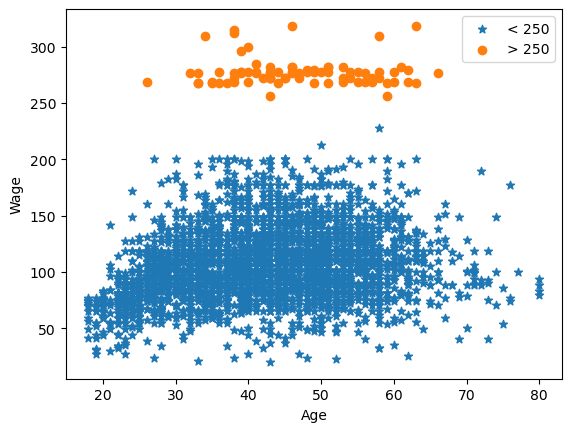

In [72]:
plt.scatter(df.age[df.wage <=250], df.wage[df.wage<=250],marker = '*', label = '< 250')
plt.scatter(df.age[df.wage >250], df.wage[df.wage>250], label = '> 250')
plt.legend()

plt.xlabel('Age')
plt.ylabel('Wage')
plt.show()

## 1. Linear Regression

Before we do anything fancy, let's just do some linear regression. It's not going to be a great fit to our data, this is just to see how we can draw the function learned. 

If I want to learn a linear model predicting `wage` from `age`, I can do the same thing we've done for the last month. 



In [73]:
from sklearn.linear_model import LinearRegression

In [74]:
X = df.age.values.reshape(-1,1)
y = df.wage

linreg = LinearRegression()

linreg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


&#9989; **<font color=red>Do this:</font>** What is the equation learned by the model? 

In [75]:
##ANSWER##
print('beta_1:', round(linreg.coef_[0],3))
print('beta_0:', round(linreg.intercept_,3))

print('wage = ', round(linreg.intercept_,3), ' + ', round(linreg.coef_[0],3), '* age')

beta_1: 0.707
beta_0: 81.705
wage =  81.705  +  0.707 * age


Now I could plot this by taking the equation I just learned and applying it to some vector of values. However, it is even easier to do this by simply predicting the outputs for a lot of the $x$-inputs and then drawing the function on top of the data.  

&#9989; **<font color=red>Do this:</font>** Use the `predict` function to get the function outputs and then plot this using the code below. 

In [77]:
##ANSWER##

t_age = np.linspace(20,80, 100).reshape(-1,1)

# your code here for y_wage
y_wage = linreg.predict(t_age)



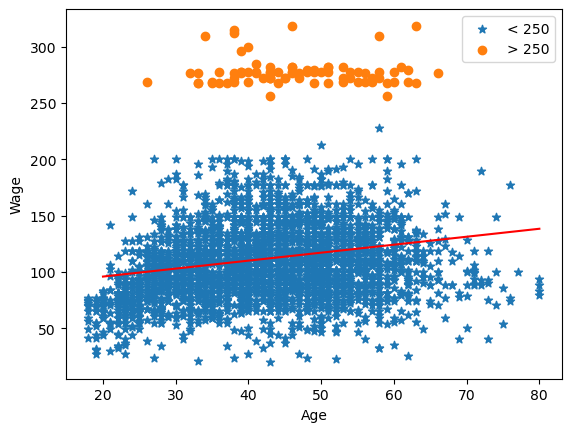

In [78]:
# If you edit the y_wage stuff above, you'll get the linear regression line drawn here.


# This is all the stuff to plot the data
plt.scatter(df.age[df.wage <=250], df.wage[df.wage<=250],marker = '*', label = '< 250')
plt.scatter(df.age[df.wage >250], df.wage[df.wage>250], label = '> 250')
plt.legend()

plt.xlabel('Age')
plt.ylabel('Wage')

# This is what I'm adding to draw the line 
plt.plot(t_age, y_wage, color = 'red')
plt.show()

# 1. Polynomial Regression 

Our first step is to build a polynomial regression model using the age data to predict wage.  So, as in class, we are in $p=1$ world here where we are going to fit the model
$$
\texttt{wage} = \beta_0 + \beta_1 \texttt{age} + \beta_2 \texttt{age}^2 + \cdots + \beta_p \texttt{age}^p +\varepsilon.
$$

The trick here is to build a matrix $X$ which has a column containing `age`, one with `age^2`, one with `age^3`, etc.  Then we hand this to your favorite regression tool (it doesn't need to know it's getting polynomial matrix inputs, it just sees a matrix of features and does it's thing). 

Here's the code we learned in [Lecture 14](../14-Ch5_1-More_KFoldCV/index.md) for building the data frame of powers of input $X$. 

In [79]:
p = 3
poly = PolynomialFeatures(p, include_bias = False)
X_powers = poly.fit_transform(X)

# X_powers

model = LinearRegression()
model.fit(X_powers,y)
print(f"Coefs: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Coefs: [ 1.01899915e+01 -1.68028587e-01  8.49452197e-04]
Intercept: -75.24391422431673


&#9989; **<font color=red>Do this:</font>** What is the equation of the model learned?  

In [80]:
##ANSWER##

# My cheating to print it out 
linestring = str(round(model.intercept_,2))
for i in range(p):
    linestring += ' + ' + str(round(model.coef_[i],2))+ ' X^'+ str(i+1)
print( 'y = ', linestring)

y =  -75.24 + 10.19 X^1 + -0.17 X^2 + 0.0 X^3


&#9989; **<font color=red>Do this:</font>** As before, in order to plot we want to determine `y_wage` from the `t_age` input below by using the `predict` command. However, note that to do this, you're going to have to pass in the polynomial matrix for the `t_age` column.  

In [82]:
##ANSWER## 
t_age = np.linspace(10,90,100).reshape(-1,1)

# Make the polynomial features from t_age 
t_powers = poly.fit_transform(t_age)

# Now predict the y values from the model and the t_powers
y_wage = model.predict(t_powers)

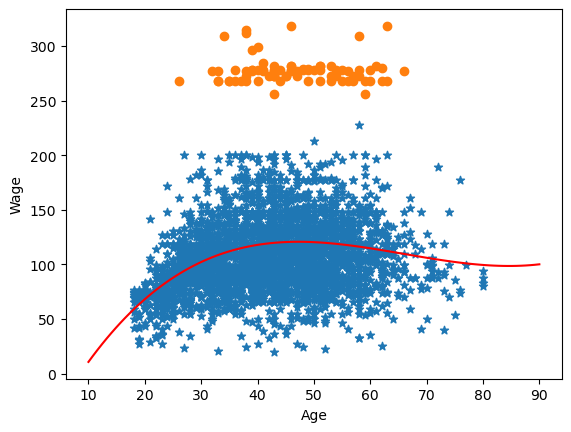

In [83]:
# Note: this should look like slide from class.
plt.scatter(df.age[df.wage <=250], df.wage[df.wage<=250],marker = '*')
plt.scatter(df.age[df.wage >250], df.wage[df.wage>250])

plt.xlabel('Age')
plt.ylabel('Wage')

plt.plot(t_age, y_wage, c= 'red')
plt.show()

# 2. Step functions

Now let's try to use step functions to learn a model using `age` to predict `wage`. Like with the polynomial example from last time, all we're going to do is build a data frame or feature matrix that has the step function values in each column, and then pass that matrix to our favorite linear modeling function. 

First, we want to get a dataframe with the cuts. 

In [84]:
df_cut, bins = pd.cut(df.age, 4, retbins = True, right = False)

Note that the `df_cut` is a pandas series with each data point now represented as the interval it's contained in. 

In [85]:
df_cut

231655    [18.0, 33.5)
86582     [18.0, 33.5)
161300    [33.5, 49.0)
155159    [33.5, 49.0)
11443     [49.0, 64.5)
              ...     
376816    [33.5, 49.0)
302281    [18.0, 33.5)
10033     [18.0, 33.5)
14375     [18.0, 33.5)
453557    [49.0, 64.5)
Name: age, Length: 3000, dtype: category
Categories (4, interval[float64, left]): [[18.0, 33.5) < [33.5, 49.0) < [49.0, 64.5) < [64.5, 80.062)]

Here I'm just printing it out in a column next to the `age` information that was used to generate it.

In [86]:
pd.DataFrame({'age': df.age, 'df_cut': df_cut}).head(10)

,age,df_cut
231655,18,"[18.0, 33.5)"
86582,24,"[18.0, 33.5)"
161300,45,"[33.5, 49.0)"
155159,43,"[33.5, 49.0)"
11443,50,"[49.0, 64.5)"
376662,54,"[49.0, 64.5)"
450601,44,"[33.5, 49.0)"
377954,30,"[18.0, 33.5)"
228963,41,"[33.5, 49.0)"
81404,52,"[49.0, 64.5)"


The `bins` output gives me the $c_i$ knots as follows. 


In [87]:
print(bins)

[18.    33.5   49.    64.5   80.062]


In [88]:
# This is how it matches with our notation.
print(r'c_1 = ', bins[0])
print(r'c_2 = ', bins[1])
print(r'c_3 = ', bins[2])
print(r'c_4 = ', bins[3])
print(r'c_5 = ', bins[4])

c_1 =  18.0
c_2 =  33.5
c_3 =  49.0
c_4 =  64.5
c_5 =  80.062


&#9989; **<font color=red>Do this:</font>**
 For each of the functions $C_0(X)$, $C_1(X)$, $C_2(X)$, $C_3(X)$, $C_4(X)$, $C_5(X)$ (following our notation in class), determine the domains where they have value 1. 

##ANSWER## 
- $C_0(X)$: $(\infty, 18)$
- $C_1(X)$: $[18.0, 33.5)$
- $C_2(X)$: $[33.5, 49.0) $
- $C_3(X)$: $[49.0, 64.5)$
- $C_4(X)$: $[64.5, 80.062)$
- $C_5(X)$: $[80.062, \infty)$

We can use the dummy variable trick to turn the `df_cut` output into something closer to what we are using. Below is my code that generates the data frame storing $C_i(X)$ for all our entries. 

In [89]:
df_steps_dummies = pd.get_dummies(df_cut) # This gives us entries with true/false
df_steps = df_steps_dummies.apply(lambda x: x * 1) # This converts those to either 0 or 1.
df_steps

,"[18.0, 33.5)","[33.5, 49.0)","[49.0, 64.5)","[64.5, 80.062)"
231655,1,0,0,0
86582,1,0,0,0
161300,0,1,0,0
155159,0,1,0,0
11443,0,0,1,0
...,...,...,...,...
376816,0,1,0,0
302281,1,0,0,0
10033,1,0,0,0
14375,1,0,0,0


&#9989; **<font color=red>Q:</font>** Which of the functions $C_i(X)$ for $i=0,\cdots, 5$ have columns represented in this matrix? *Note: it's not all of them*


##ANSWER## 

It has $C_1, \cdots, C_4$. Basically the infinite interval ones $C_0$ and $C_5$ are dropped. 

The function I'm learning is 

$$
f(X) = \beta_0 + \beta_1*C_1(X) + \beta_2 * C_2(X) + \beta_3*C_3(X) + \beta_4*C_4(X)
$$

&#9989; **<font color=red>Do this:</font>** Pass this matrix to a linear regression model and use it to predict `wage`. What is the equation for your learned model? 

In [91]:
##ANSWER##
linreg = LinearRegression()
linreg.fit(df_steps,df.wage)

print(linreg.coef_)
print(linreg.intercept_)

[-13.86486835  10.06828118  10.02086382  -6.22427665]
108.02326038076104


&#9989; **<font color=red>Do this:</font>**  Be specific in terms of the $C_i$ functions you learned earlier.

In [92]:
##ANSWER##
coefs = [f"{beta:0.2e}" for beta in linreg.coef_]
eqstring = f"{linreg.intercept_:.2f}"

for i in range(len(coefs)):
    eqstring += ' + ' + coefs[i] + ' C_' + str(i+1) + '(X)'

print(eqstring)

108.02 + -1.39e+01 C_1(X) + 1.01e+01 C_2(X) + 1.00e+01 C_3(X) + -6.22e+00 C_4(X)


Assuming you stored your linear regression model as `linreg`, the following code will plot the learned function. Check that the answers you got in the table above match with what you're seeing in the graph.  

In [93]:
t_age = pd.Series(np.linspace(20,80,100))
t_df_cut = pd.cut(t_age, bins, right = False) #<-- I'm explicitly passing the same bins learned above so tha the procedure is the same. 

t_dummies = pd.get_dummies(t_df_cut)
t_step = t_dummies.apply(lambda x: x * 1)

t_step.head()

,"[18.0, 33.5)","[33.5, 49.0)","[49.0, 64.5)","[64.5, 80.062)"
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,1,0,0,0
4,1,0,0,0


&#9989; **<font color=red>Do this:</font>** Above, I figured out the transformation of the input `t_age` values to do the same transformation as our step function. Now use the linear regression model learned to predict `y_wage`, then we can graph it. 

In [94]:
##ANSWER##
y_wage = linreg.predict(t_dummies) 

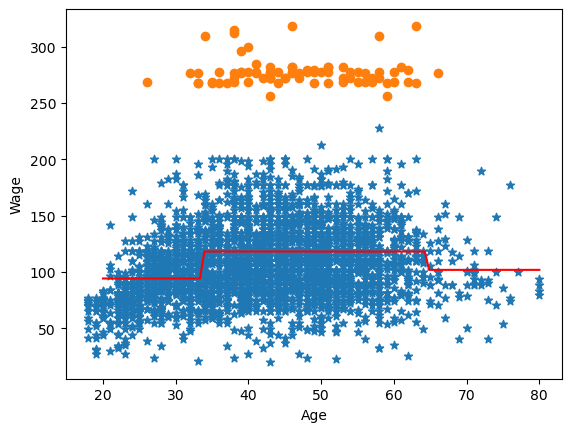

In [95]:
plt.scatter(df.age[df.wage <=250], df.wage[df.wage<=250],marker = '*')
plt.scatter(df.age[df.wage >250], df.wage[df.wage>250])
plt.xlabel('Age')
plt.ylabel('Wage')

plt.plot(t_age, y_wage,color='red')
plt.show()



-----
### Congratulations, we're done!
Initially created by Dr. Liz Munch, modified by Dr. Lianzhang Bao and Dr. Firas Khasawneh, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [109]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

from jupyterinstruct import InstructorNotebook
import os
this_notebook = os.path.basename(globals()['__vsc_ipynb_file__'])

studentnotebook = InstructorNotebook.makestudent(this_notebook)

InstructorNotebook.validate(studentnotebook)

<IPython.core.display.Javascript object>

Myfilename CMSE381-Lec22-PolynomialAndStepFunctions-INSTRUCTOR.ipynb


CMSE381-Lec22_PolynomialAndStepFunctions.ipynb


Validating Notebook ./CMSE381-Lec22_PolynomialAndStepFunctions.ipynb


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


   ERROR: File Doesn't Exist - ../14-Ch5_1-More_KFoldCV/


1